In [35]:
!pip -q install line_profiler[ipython]

In [9]:
import sys
from pathlib import Path

sys.path.append(str(Path("../scripts").resolve()))

import pandas as pd
import geopandas as gpd
import antimeridian
import xarray as xr
import shapely
from data_access import catalog, maap_search_to_gdf, EC_COLLECTION
from gpm_earthcare_colocation import make_earthcare_gdf

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
bounds = shapely.Polygon(
    [[-180,-30], [-180,30], [180,30], [180,-30]]
)

In [11]:
from products_list import PRODUCTS

In [54]:
ec_gdfs = {
    product:make_earthcare_gdf(
        catalog.search(
            collections=EC_COLLECTION, 
            datetime=("2024-08-10T00:00:00", "2024-10-01T00:00:00"), 
            bbox=bounds.bounds, 
            filter=f"(productType = '{product}')",
            method = 'GET', # This is necessary 
        )
    )
    for product in PRODUCTS
}

In [59]:
multi_ec_gdf = ec_gdfs["ACM_CAP_2B"].rename(
    dict(
        enclosure_h5=f'enclosure_{"ACM_CAP_2B"}',
    ), 
    axis=1
).drop(
    ["product", "baseline"], axis=1
).set_index("granule")

for k, v in ec_gdfs.items():
    if k != "ACM_CAP_2B":
        multi_ec_gdf = multi_ec_gdf.join(
            v.rename(
                dict(
                    enclosure_h5=f'enclosure_{k}',
                ), 
                axis=1
            ).drop(
                ["product", "baseline", "date", "start_time", "end_time", "geometry"], axis=1
            ).set_index("granule"), 
            how="inner"
        )

In [60]:
multi_ec_gdf

,date,start_time,end_time,enclosure_ACM_CAP_2B,geometry,enclosure_AC__TC__2B,enclosure_ACM_RT__2B,enclosure_ALL_DF__2B,enclosure_ATL_EBD_2A,enclosure_CPR_CD__2A,enclosure_CPR_FMR_2A
granule,,,,,,,,,,,
01141F,2024-08-10 07:34:56,2024-08-10 07:34:56,2024-08-10 07:46:45,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (93.89939 -22.47529, 92.81608 -27.5...",https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
01141H,2024-08-10 07:57:53,2024-08-10 07:57:53,2024-08-10 08:09:42,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (-71.87141 -67.47009, -75.67799 -62...",https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
01142A,2024-08-10 08:09:42,2024-08-10 08:09:42,2024-08-10 08:21:18,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (-89.01486 -22.46883, -90.02644 -17...",https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
01142B,2024-08-10 08:21:18,2024-08-10 08:21:18,2024-08-10 08:33:05,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (-97.6988 22.53005, -98.7805 27.597...",https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
01142D,2024-08-10 08:44:10,2024-08-10 08:44:10,2024-08-10 08:55:57,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (96.5757 67.49116, 92.7632 62.63036...",https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
...,...,...,...,...,...,...,...,...,...,...,...
01945A,2024-09-30 22:51:59,2024-09-30 22:51:59,2024-09-30 23:03:35,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (50.10356 -22.5167, 49.09064 -17.52...",https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
01945B,2024-09-30 23:03:35,2024-09-30 23:03:35,2024-09-30 23:15:21,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (41.41217 22.50158, 40.33075 27.568...",https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
01945D,2024-09-30 23:26:25,2024-09-30 23:26:25,2024-09-30 23:38:11,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (-124.268 67.51398, -128.08978 62.6...",https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...

<Axes: >

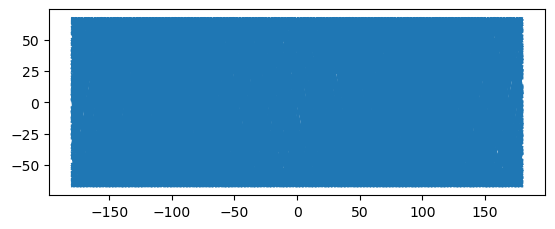

In [61]:
multi_ec_gdf.plot()

In [62]:
multi_ec_gdf.to_file('EC_orcestra_tracks.gpkg', driver='GPKG', layer='name')